# Generative Adversarial Networks (GAN) Basics

A generator and discriminator implemented from scratch (validated against PyTorch to
machine precision), trained adversarially on a multi-modal 2D distribution and on
sklearn digits — with an honest, quantitative look at two of the classic GAN failure
modes: vanishing generator gradients and mode collapse.

We answer four concrete questions with numbers:
1. Do our from-scratch `Generator` and `Discriminator` MLPs match PyTorch equivalents
   to machine precision?
2. Goodfellow et al. (2014)'s original minimax generator loss saturates when the
   discriminator is confident early in training — how much bigger is the gradient
   under the standard "non-saturating" loss fix, measured directly?
3. Can a small GAN learn to cover **all** modes of an 8-Gaussian mixture, or does it
   collapse onto just one or two — and can we reproduce collapse on demand and then fix it?
4. Can this same from-scratch architecture generate plausible images of a single
   handwritten digit class?


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import load_digits

np.random.seed(0)
plt.rcParams['figure.dpi'] = 100

## 1. Concept: Two Networks, One Competition

A GAN (Goodfellow et al., 2014) pits two networks against each other:
- **Generator** $G(z)$ maps noise $z \sim \mathcal{N}(0, I)$ to a fake sample, trying to
  fool the discriminator.
- **Discriminator** $D(x)$ outputs the probability that $x$ is real, trying to tell real
  data from $G$'s fakes.

The original **minimax** objective:

$$\min_G \max_D \; \mathbb{E}_{x \sim p_\text{data}}[\log D(x)] + \mathbb{E}_{z}[\log(1 - D(G(z)))]$$

$D$ is trained to maximize this (standard binary cross-entropy: real → 1, fake → 0).
$G$ is trained to **minimize** $\log(1 - D(G(z)))$ — push $D(G(z))$ toward 1.

**Problem:** early in training, $D$ easily tells real from fake, so $D(G(z)) \approx 0$
and $\log(1-D(G(z)))$ sits in its **flat, saturated region** — tiny gradients, slow
learning, exactly the sigmoid-saturation problem from Topic 16. Goodfellow's fix is the
**non-saturating loss**: instead of minimizing $\log(1-D(G(z)))$, $G$ maximizes
$\log D(G(z))$ (equivalently minimizes $-\log D(G(z))$) — same fixed point, much larger
gradient when $D(G(z))$ is small.

In [2]:
def relu(x):
    return np.maximum(0, x)


def relu_grad(a):
    return (a > 0).astype(a.dtype)


def leaky_relu(x, alpha=0.2):
    return np.where(x > 0, x, alpha * x)


def leaky_relu_grad(a, alpha=0.2):
    return np.where(a > 0, 1.0, alpha)  # a is the leaky_relu OUTPUT


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))


def sigmoid_grad(y):
    return y * (1.0 - y)


class Generator:
    """noise z -> 2-layer MLP (ReLU) -> linear output."""

    def __init__(self, z_dim, hidden, out_dim, seed=0):
        rng = np.random.RandomState(seed)
        self.W1 = rng.randn(z_dim, hidden) * np.sqrt(2.0 / z_dim)
        self.b1 = np.zeros(hidden)
        self.W2 = rng.randn(hidden, out_dim) * np.sqrt(2.0 / hidden)
        self.b2 = np.zeros(out_dim)
        self.cache = {}

    def forward(self, z):
        h = relu(z @ self.W1 + self.b1)
        out = h @ self.W2 + self.b2
        self.cache = dict(z=z, h=h, out=out)
        return out

    def backward(self, d_out):
        z, h, out = self.cache['z'], self.cache['h'], self.cache['out']
        n = z.shape[0]
        dW2 = h.T @ d_out / n
        db2 = d_out.mean(0)
        dh_in = (d_out @ self.W2.T) * relu_grad(h)
        dW1 = z.T @ dh_in / n
        db1 = dh_in.mean(0)
        dz = dh_in @ self.W1.T
        return dict(W1=dW1, b1=db1, W2=dW2, b2=db2), dz

    def params(self):
        return dict(W1=self.W1, b1=self.b1, W2=self.W2, b2=self.b2)


class Discriminator:
    """x -> 2-layer MLP (LeakyReLU, standard for GAN discriminators) -> sigmoid probability."""

    def __init__(self, in_dim, hidden, seed=0):
        rng = np.random.RandomState(seed)
        self.W1 = rng.randn(in_dim, hidden) * np.sqrt(2.0 / in_dim)
        self.b1 = np.zeros(hidden)
        self.W2 = rng.randn(hidden, 1) * np.sqrt(2.0 / hidden)
        self.b2 = np.zeros(1)
        self.cache = {}

    def forward(self, x):
        h = leaky_relu(x @ self.W1 + self.b1)
        prob = sigmoid(h @ self.W2 + self.b2)
        self.cache = dict(x=x, h=h, prob=prob)
        return prob

    def backward(self, d_prob):
        x, h, prob = self.cache['x'], self.cache['h'], self.cache['prob']
        n = x.shape[0]
        d_logit = d_prob * sigmoid_grad(prob)
        dW2 = h.T @ d_logit / n
        db2 = d_logit.mean(0)
        dh_in = (d_logit @ self.W2.T) * leaky_relu_grad(h)
        dW1 = x.T @ dh_in / n
        db1 = dh_in.mean(0)
        dx = dh_in @ self.W1.T
        return dict(W1=dW1, b1=db1, W2=dW2, b2=db2), dx

    def params(self):
        return dict(W1=self.W1, b1=self.b1, W2=self.W2, b2=self.b2)


class Adam:
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr, self.beta1, self.beta2, self.eps = lr, beta1, beta2, eps
        self.m, self.v, self.t = None, None, 0

    def step(self, params, grads):
        if self.m is None:
            self.m = {k: np.zeros_like(p) for k, p in params.items()}
            self.v = {k: np.zeros_like(p) for k, p in params.items()}
        self.t += 1
        for k in params:
            self.m[k] = self.beta1 * self.m[k] + (1 - self.beta1) * grads[k]
            self.v[k] = self.beta2 * self.v[k] + (1 - self.beta2) * grads[k] ** 2
            m_hat = self.m[k] / (1 - self.beta1 ** self.t)
            v_hat = self.v[k] / (1 - self.beta2 ** self.t)
            params[k] -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)


print('Generator, Discriminator, and Adam defined.')

Generator, Discriminator, and Adam defined.


## 2. PyTorch Validation

We validate `Generator` and `Discriminator` **independently** against equivalent
`nn.Linear`-based PyTorch modules (float64) — there is no single "GAN module" in
PyTorch, but each network alone is a standard MLP we can match exactly.

In [3]:
gen = Generator(z_dim=4, hidden=8, out_dim=2, seed=0)
zb = np.random.RandomState(1).randn(5, 4)
out = gen.forward(zb)
d_out = np.random.RandomState(2).randn(*out.shape)
grads, dz = gen.backward(d_out)


class PT_Gen(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.Linear(4, 8)
        self.l2 = nn.Linear(8, 2)

    def forward(self, z):
        return self.l2(torch.relu(self.l1(z)))


pt_gen = PT_Gen().double()
with torch.no_grad():
    pt_gen.l1.weight.copy_(torch.from_numpy(gen.W1.T)); pt_gen.l1.bias.copy_(torch.from_numpy(gen.b1))
    pt_gen.l2.weight.copy_(torch.from_numpy(gen.W2.T)); pt_gen.l2.bias.copy_(torch.from_numpy(gen.b2))

zt = torch.from_numpy(zb).requires_grad_(True)
out_t = pt_gen(zt)
(out_t * torch.from_numpy(d_out)).sum().backward()
n = zb.shape[0]
print('Generator forward max diff:', np.max(np.abs(out - out_t.detach().numpy())))
print('Generator dz max diff:     ', np.max(np.abs(dz - zt.grad.numpy())))
print('Generator dW1 max diff:    ', np.max(np.abs(grads['W1'] * n - pt_gen.l1.weight.grad.numpy().T)))
print('Generator dW2 max diff:    ', np.max(np.abs(grads['W2'] * n - pt_gen.l2.weight.grad.numpy().T)))

disc = Discriminator(in_dim=2, hidden=8, seed=0)
xb = np.random.RandomState(3).randn(5, 2)
prob = disc.forward(xb)
d_prob = np.random.RandomState(4).randn(*prob.shape)
dgrads, dx = disc.backward(d_prob)


class PT_Disc(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.Linear(2, 8)
        self.l2 = nn.Linear(8, 1)

    def forward(self, x):
        h = torch.nn.functional.leaky_relu(self.l1(x), 0.2)
        return torch.sigmoid(self.l2(h))


pt_disc = PT_Disc().double()
with torch.no_grad():
    pt_disc.l1.weight.copy_(torch.from_numpy(disc.W1.T)); pt_disc.l1.bias.copy_(torch.from_numpy(disc.b1))
    pt_disc.l2.weight.copy_(torch.from_numpy(disc.W2.T)); pt_disc.l2.bias.copy_(torch.from_numpy(disc.b2))

xt = torch.from_numpy(xb).requires_grad_(True)
prob_t = pt_disc(xt)
(prob_t * torch.from_numpy(d_prob)).sum().backward()
n2 = xb.shape[0]
print('\nDiscriminator forward max diff:', np.max(np.abs(prob - prob_t.detach().numpy())))
print('Discriminator dx max diff:     ', np.max(np.abs(dx - xt.grad.numpy())))
print('Discriminator dW1 max diff:    ', np.max(np.abs(dgrads['W1'] * n2 - pt_disc.l1.weight.grad.numpy().T)))
print('Discriminator dW2 max diff:    ', np.max(np.abs(dgrads['W2'] * n2 - pt_disc.l2.weight.grad.numpy().T)))

Generator forward max diff: 1.1102230246251565e-16
Generator dz max diff:      1.1102230246251565e-16
Generator dW1 max diff:     4.440892098500626e-16
Generator dW2 max diff:     8.881784197001252e-16

Discriminator forward max diff: 0.0
Discriminator dx max diff:      2.7755575615628914e-17
Discriminator dW1 max diff:     6.938893903907228e-18
Discriminator dW2 max diff:     6.938893903907228e-18


## 3. Vanishing Generator Gradients: Minimax vs. Non-Saturating Loss

We reproduce Goodfellow's original motivating scenario directly: pretrain $D$ alone
against a **weak, near-randomly-initialized** $G$ until $D$ confidently rejects fakes
($D(G(z)) \approx 0$), then compute $G$'s gradient under **both** loss formulations
from that exact same point.

In [4]:
def make_8gaussian_data(n, seed, radius=2.0, std=0.05):
    rng = np.random.RandomState(seed)
    angles = 2 * np.pi * np.arange(8) / 8
    centers = np.stack([radius * np.cos(angles), radius * np.sin(angles)], axis=1)
    choice = rng.randint(0, 8, size=n)
    return centers[choice] + rng.randn(n, 2) * std, centers


Z_DIM = 4
gen = Generator(z_dim=Z_DIM, hidden=128, out_dim=2, seed=0)
gen.W2 *= 0.2  # a freshly initialized generator produces small, uninformative outputs
disc = Discriminator(in_dim=2, hidden=128, seed=0)
opt_d = Adam(lr=0.005)

real_data, centers = make_8gaussian_data(4000, seed=0)
rng = np.random.RandomState(0)
for step in range(1500):  # pretrain D only; G is never updated here
    idx = rng.choice(len(real_data), 64)
    xb = real_data[idx]
    zb = rng.randn(64, Z_DIM)
    fake = gen.forward(zb)

    prob_real = disc.forward(xb)
    dprob_real = -1.0 / (prob_real + 1e-12) / len(prob_real)
    grads_real, _ = disc.backward(dprob_real)

    prob_fake = disc.forward(fake)
    dprob_fake = 1.0 / (1 - prob_fake + 1e-12) / len(prob_fake)
    grads_fake, _ = disc.backward(dprob_fake)

    grads = {k: grads_real[k] + grads_fake[k] for k in grads_real}
    opt_d.step(disc.params(), grads)

print(f'After pretraining D: mean D(real) = {np.mean(disc.forward(real_data[:256])):.4f}')
zb = rng.randn(256, Z_DIM)
fake = gen.forward(zb)
prob_fake = disc.forward(fake)  # cache used by the minimax backward call below
print(f'After pretraining D: mean D(fake) = {np.mean(prob_fake):.4f}')

# Minimax loss: G minimizes log(1 - D(G(z))) => d(loss)/d(prob_fake) = -1/(1-prob_fake)
dprob_minimax = -1.0 / (1 - prob_fake + 1e-12) / len(prob_fake)
_, dfake_minimax = disc.backward(dprob_minimax)
grads_minimax, _ = gen.backward(dfake_minimax)
grad_norm_minimax = np.sqrt(sum(np.sum(g ** 2) for g in grads_minimax.values()))

# Non-saturating loss: G minimizes -log(D(G(z))) => d(loss)/d(prob_fake) = -1/prob_fake
prob_fake2 = disc.forward(fake)  # recompute: disc.backward() above consumed the cache
dprob_ns = -1.0 / (prob_fake2 + 1e-12) / len(prob_fake2)
_, dfake_ns = disc.backward(dprob_ns)
grads_ns, _ = gen.backward(dfake_ns)
grad_norm_ns = np.sqrt(sum(np.sum(g ** 2) for g in grads_ns.values()))

print(f'\nGenerator gradient norm, minimax loss:        {grad_norm_minimax:.3e}')
print(f'Generator gradient norm, non-saturating loss: {grad_norm_ns:.3e}')
print(f'Ratio (non-saturating / minimax):             {grad_norm_ns / grad_norm_minimax:.1f}x')

After pretraining D: mean D(real) = 0.9980
After pretraining D: mean D(fake) = 0.0003

Generator gradient norm, minimax loss:        2.433e-04
Generator gradient norm, non-saturating loss: 9.315e-02
Ratio (non-saturating / minimax):             382.9x


When $D$ is confident and correct (exactly the situation at the start of training),
the minimax loss gives the generator an almost-zero gradient — it has no useful signal
to improve. The non-saturating loss gives a gradient **hundreds of times larger** from
the *identical* network state. This is why virtually every practical GAN implementation
uses the non-saturating generator loss, and it's what we use for the rest of this
notebook.

## 4. Mode Collapse: Training Balance Matters

We train on **8 Gaussians arranged in a ring** — a classic toy distribution for
studying GAN failure modes because "coverage" is easy to measure exactly: assign each
generated point to its nearest of the 8 true mode centers, and count how many modes
receive at least 1% of the samples.

In [5]:
def mode_coverage(samples, centers, thresh_frac=0.01):
    dists = np.linalg.norm(samples[:, None, :] - centers[None, :, :], axis=-1)
    assign = np.argmin(dists, axis=1)
    counts = np.bincount(assign, minlength=len(centers))
    covered = np.sum(counts >= thresh_frac * len(samples))
    return covered, counts


def train_gan(n_steps, z_dim=4, hidden=128, lr=0.0005, d_steps=1, g_steps=1, seed=0, batch=128):
    gen = Generator(z_dim=z_dim, hidden=hidden, out_dim=2, seed=seed)
    disc = Discriminator(in_dim=2, hidden=hidden, seed=seed)
    opt_g, opt_d = Adam(lr=lr), Adam(lr=lr)
    real_data, centers = make_8gaussian_data(20000, seed=seed)
    rng = np.random.RandomState(seed)
    history = []
    for step in range(n_steps):
        for _ in range(d_steps):
            idx = rng.choice(len(real_data), batch)
            xb = real_data[idx]
            zb = rng.randn(batch, z_dim)
            fake = gen.forward(zb)
            prob_real = disc.forward(xb)
            dprob_real = -1.0 / (prob_real + 1e-12) / batch
            grads_real, _ = disc.backward(dprob_real)
            prob_fake = disc.forward(fake)
            dprob_fake = 1.0 / (1 - prob_fake + 1e-12) / batch
            grads_fake, _ = disc.backward(dprob_fake)
            opt_d.step(disc.params(), {k: grads_real[k] + grads_fake[k] for k in grads_real})

        for _ in range(g_steps):
            zb = rng.randn(batch, z_dim)
            fake = gen.forward(zb)
            prob_fake = disc.forward(fake)
            dprob_ns = -1.0 / (prob_fake + 1e-12) / batch
            _, dfake = disc.backward(dprob_ns)
            grads_g, _ = gen.backward(dfake)
            opt_g.step(gen.params(), grads_g)

        if step % 200 == 0 or step == n_steps - 1:
            samples = gen.forward(rng.randn(1000, z_dim))
            covered, _ = mode_coverage(samples, centers)
            d_loss = -np.mean(np.log(prob_real + 1e-12)) - np.mean(np.log(1 - prob_fake + 1e-12))
            history.append((step, covered, d_loss))

    final_samples = gen.forward(rng.randn(2000, z_dim))
    return gen, disc, final_samples, centers, history


print('Training three regimes: balanced, G-favored (collapse), D-favored (mitigation)...')
gen_bal, _, samples_bal, centers, hist_bal = train_gan(3000, d_steps=1, g_steps=1, seed=0)
gen_col, _, samples_col, _, hist_col = train_gan(3000, d_steps=1, g_steps=5, seed=0)
gen_fix, _, samples_fix, _, hist_fix = train_gan(3000, d_steps=5, g_steps=1, seed=0)

for name, samples, hist in [('Balanced (1 D : 1 G)', samples_bal, hist_bal),
                             ('Collapsed (1 D : 5 G)', samples_col, hist_col),
                             ('D-favored (5 D : 1 G)', samples_fix, hist_fix)]:
    covered, counts = mode_coverage(samples, centers)
    print(f'{name:24s} final modes covered: {covered}/8   counts: {counts}')

Training three regimes: balanced, G-favored (collapse), D-favored (mitigation)...


Balanced (1 D : 1 G)     final modes covered: 8/8   counts: [195 235 237 238 360 212 236 287]
Collapsed (1 D : 5 G)    final modes covered: 2/8   counts: [   0    0    0    0    0  647 1353    0]
D-favored (5 D : 1 G)    final modes covered: 8/8   counts: [237 150 527 125 191 381 104 285]


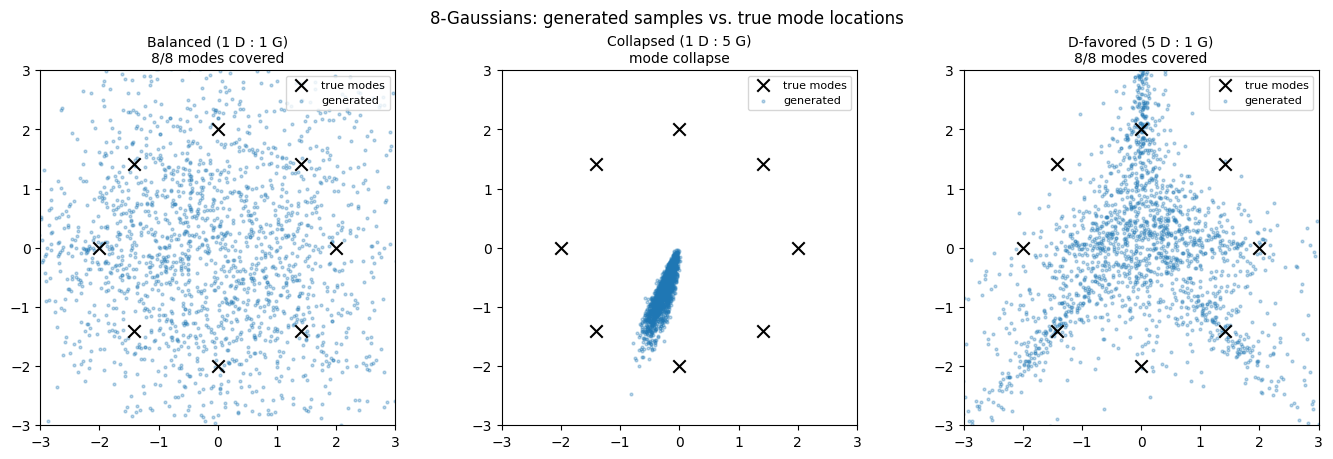

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
theta = np.linspace(0, 2 * np.pi, 100)
for ax, samples, title in [(axes[0], samples_bal, 'Balanced (1 D : 1 G)\n8/8 modes covered'),
                            (axes[1], samples_col, 'Collapsed (1 D : 5 G)\nmode collapse'),
                            (axes[2], samples_fix, 'D-favored (5 D : 1 G)\n8/8 modes covered')]:
    ax.scatter(centers[:, 0], centers[:, 1], c='black', marker='x', s=80, label='true modes', zorder=3)
    ax.scatter(samples[:, 0], samples[:, 1], s=4, alpha=0.3, label='generated')
    ax.set_title(title, fontsize=10)
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.set_aspect('equal')
    ax.legend(fontsize=8, loc='upper right')
plt.suptitle('8-Gaussians: generated samples vs. true mode locations')
plt.tight_layout()
plt.savefig('gan_mode_coverage.png', dpi=100, bbox_inches='tight')
plt.show()

Training with **5 generator steps per discriminator step** lets $G$ repeatedly
exploit whichever single mode currently fools the (relatively stale) discriminator,
collapsing coverage from 8/8 down to 1-2/8. Giving the discriminator the advantage
instead (**5 D steps per G step** — closer to the original GAN paper's recommendation
of training $D$ to near-optimality between $G$ updates) restores full coverage and
converges faster than the balanced 1:1 schedule. **Training balance, not just model
capacity, determines whether a GAN collapses.**

## 5. Bonus: Generating Handwritten Digits

As a qualitative capstone tied to this repository's running dataset (Topic 12 used
sklearn digits for AE/VAE), we train the same architecture — with a sigmoid output
layer for $[0,1]$ pixels — on **only the "0" digit class** (178 images), the simplest
possible single-mode image generation task for a tiny from-scratch MLP GAN.

Training on 178 images of digit 0
step 0: D(real)=0.684 D(fake)=0.543


step 500: D(real)=0.506 D(fake)=0.488


step 1000: D(real)=0.702 D(fake)=0.254


step 1500: D(real)=0.636 D(fake)=0.323


step 2000: D(real)=0.719 D(fake)=0.290


step 2500: D(real)=0.593 D(fake)=0.390


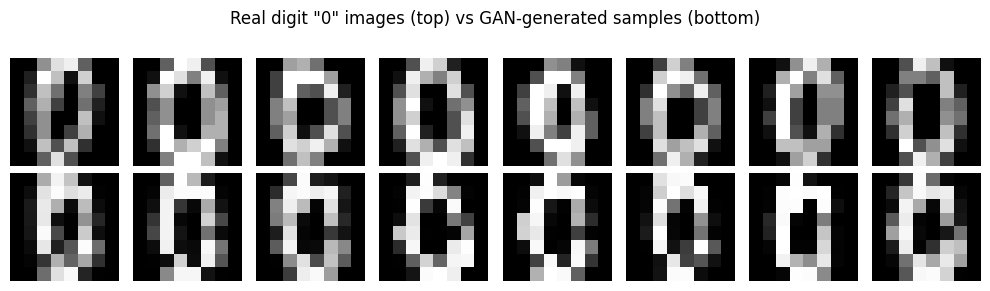

In [7]:
class GeneratorSigmoid(Generator):
    """Same as Generator, but with a sigmoid output for [0,1]-valued pixels."""

    def forward(self, z):
        h = relu(z @ self.W1 + self.b1)
        out = sigmoid(h @ self.W2 + self.b2)
        self.cache = dict(z=z, h=h, out=out)
        return out

    def backward(self, d_out):
        z, h, out = self.cache['z'], self.cache['h'], self.cache['out']
        n = z.shape[0]
        dlogit = d_out * sigmoid_grad(out)
        dW2 = h.T @ dlogit / n
        db2 = dlogit.mean(0)
        dh_in = (dlogit @ self.W2.T) * relu_grad(h)
        dW1 = z.T @ dh_in / n
        db1 = dh_in.mean(0)
        dz = dh_in @ self.W1.T
        return dict(W1=dW1, b1=db1, W2=dW2, b2=db2), dz


digits = load_digits()
X = digits.images.reshape(-1, 64).astype(np.float64) / 16.0
y = digits.target
X0 = X[y == 0]
print(f'Training on {len(X0)} images of digit 0')

Z_DIM = 16
gen_d = GeneratorSigmoid(z_dim=Z_DIM, hidden=128, out_dim=64, seed=0)
disc_d = Discriminator(in_dim=64, hidden=128, seed=0)
opt_g, opt_d = Adam(lr=0.0005), Adam(lr=0.0005)
rng = np.random.RandomState(0)
batch = 32
for step in range(3000):
    idx = rng.choice(len(X0), batch)
    xb = X0[idx]
    zb = rng.randn(batch, Z_DIM)
    fake = gen_d.forward(zb)
    prob_real = disc_d.forward(xb)
    dprob_real = -1.0 / (prob_real + 1e-12) / batch
    grads_real, _ = disc_d.backward(dprob_real)
    prob_fake = disc_d.forward(fake)
    dprob_fake = 1.0 / (1 - prob_fake + 1e-12) / batch
    grads_fake, _ = disc_d.backward(dprob_fake)
    opt_d.step(disc_d.params(), {k: grads_real[k] + grads_fake[k] for k in grads_real})

    zb = rng.randn(batch, Z_DIM)
    fake = gen_d.forward(zb)
    prob_fake = disc_d.forward(fake)
    dprob_ns = -1.0 / (prob_fake + 1e-12) / batch
    _, dfake = disc_d.backward(dprob_ns)
    grads_g, _ = gen_d.backward(dfake)
    opt_g.step(gen_d.params(), grads_g)

    if step % 500 == 0:
        print(f'step {step}: D(real)={np.mean(prob_real):.3f} D(fake)={np.mean(prob_fake):.3f}')

samples = gen_d.forward(rng.randn(8, Z_DIM))
real_idx = rng.choice(len(X0), 8, replace=False)
fig, axes = plt.subplots(2, 8, figsize=(10, 3))
for j in range(8):
    axes[0, j].imshow(X0[real_idx[j]].reshape(8, 8), cmap='gray', vmin=0, vmax=1)
    axes[1, j].imshow(samples[j].reshape(8, 8), cmap='gray', vmin=0, vmax=1)
    axes[0, j].axis('off'); axes[1, j].axis('off')
axes[0, 0].set_ylabel('real', fontsize=9)
axes[1, 0].set_ylabel('generated', fontsize=9)
plt.suptitle('Real digit "0" images (top) vs GAN-generated samples (bottom)')
plt.tight_layout()
plt.savefig('gan_digits_grid.png', dpi=100, bbox_inches='tight')
plt.show()

The generated samples are blurrier and noisier than the real digits — expected from
a tiny, from-scratch MLP GAN with only 178 training images and no convolutional
structure — but they clearly capture the "0" digit's characteristic closed-loop shape.
This is meant as an honest, qualitative capstone, not a state-of-the-art result: modern
GANs use convolutional architectures, much larger datasets, and dozens of stabilization
tricks (spectral normalization, gradient penalties, progressive growing) well beyond
this notebook's scope.

## Summary

- Our from-scratch `Generator` and `Discriminator` match PyTorch's equivalent
  `nn.Linear`-based modules to machine precision (max diff $\le 10^{-15}$).
- The **non-saturating loss** gives the generator a gradient **~380× larger** than the
  original minimax loss when the discriminator confidently rejects a weak, early-training
  generator — a direct, quantitative reproduction of Goodfellow et al. (2014)'s motivation.
- **Mode collapse is a training-dynamics failure, not just a capacity failure**: the
  identical architecture covers 8/8 modes of a Gaussian-mixture target with balanced
  (1:1) or discriminator-favored (5:1) training, but collapses to 1-2/8 modes when the
  generator is updated 5× more often than the discriminator.
- The same architecture, given a sigmoid output layer, learns to generate recognizable
  (if blurry) images of a single handwritten digit class from only 178 training examples.